Plot Figure 4
--

In [2]:
cd ~/Pythons/

/home/users/guicha/Pythons


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from config import IUMFIGDIR
from utils.stats import *
from IUM.make_anomalies.twb.make_twb_radius_ctrl_rm import load_twb_radius_ctrl_rm
from IUM.make_anomalies.twb.make_twb_radius_pert_rm import load_twb_radius_pert_rm

Done
Done
Done
Done
Done
Done


In [9]:
var = 'twb'
res = 0.5
value = 0.3
value_pert = 1.
lengths = [25, 50, 100]
u = 4.
env = 'stable'
date = '10010101'
time = 19
window = 3

if var == 'twb':
    var_ = 'Twb'
    ylims = (-2., 2.)
    legloc = 'upper center'
elif var == 'hi':
    var_ = 'HI'
    ylims = (-6., 6.)
    legloc = 'lower center'

env_ref = env
u_ref = u
lengths_ref = [25, 30, 35, 50, 75, 100, 125, 150]

us = [2., 8.]
dTzs = ['stabledTz-', 'stabledTz+']
dqzs = ['stableRH-', 'stableRH+']

In [12]:
wet_std_all = []
anos_ref = {}

for length in lengths_ref:
    data_wet = load_twb_radius_ctrl_rm(res=res, variable=var, value=value_pert, u=u_ref, env=env_ref, date=date, window=window)
    val_wet = data_wet[length/2][0].isel(time=time-1).values
    val_wet_std = data_wet[length/2][1].isel(time=time-1).values

    wet_std_all.append(val_wet_std)

    data = load_twb_radius_pert_rm(res=res, variable=var, value=value, value_pert=value_pert, length=length, u=u_ref, env=env_ref, date=date, window=window)
    data_r_max = data[length/2][0].isel(time=time-1).values
    data_r_max_std = data[length/2][1].isel(time=time-1).values

    ano_ref = data_r_max - val_wet

    # Compute significance: Welch test
    area = math.pi * (length/2)**2
    n = area / (res**2)
    tstat = welch_stat(data_r_max, val_wet, data_r_max_std, val_wet_std, n, n)
    dof = welch_dof(data_r_max_std, val_wet_std, n, n)
    test = welch_test(tstat, dof, 0.05)

    print('%i km: %.2f (%s)'%(length, ano_ref, test))

    anos_ref[length] = (ano_ref, data_r_max_std, test)


# U

out_anos_u = {}

for u in us:
    print('\n>>> %.1f <<<'%u)

    data_wet = load_twb_radius_ctrl_rm(res=res, variable=var, value=value_pert, u=u, env=env_ref, date=date, window=window)

    vals_ano = {}

    if u == 2.:
        lengths_ = [15, 25, 35, 50, 100] #] + lengths
    elif u == 8.:
        lengths_ = lengths + [150]
    else:
        lengths_ = lengths

    for length in lengths_:
        val_wet = data_wet[length/2][0].isel(time=time-1).values
        val_wet_std = data_wet[length/2][1].isel(time=time-1).values

        wet_std_all.append(val_wet_std)

        data = load_twb_radius_pert_rm(res=res, variable=var, value=value, value_pert=value_pert, length=length, u=u, env=env_ref, date=date, window=window)
        data_r_max = data[length/2][0].isel(time=time-1).values
        data_r_max_std = data[length/2][1].isel(time=time-1).values

        ano_u = data_r_max - val_wet

        area = math.pi * (length/2)**2
        n = area / (res**2)
        tstat = welch_stat(data_r_max, val_wet, data_r_max_std, val_wet_std, n, n)
        dof = welch_dof(data_r_max_std, val_wet_std, n, n)
        test = welch_test(tstat, dof, 0.05)

        print('%i km: %.2f (%s)'%(length, ano_u, test))

        vals_ano[length] = (ano_u, data_r_max_std, test)  # ano_ano -> anomaly with respect to default case anomaly

    out_anos_u[u] = vals_ano


# dT/dz

out_anos_dTz = {}

for dTz in dTzs:
    print('\n>>> %s <<<'%dTz)

    data_wet = load_twb_radius_ctrl_rm(res=res, variable=var, value=value_pert, u=u_ref, env=dTz, date=date, window=window)

    vals_ano = {}

    if dTz == 'stabledTz-':
        lengths_ = [25, 50, 100]
    elif dTz == 'stabledTz+':
        lengths_ = [25, 50, 100]  # 15,

    for length in lengths_:
        val_wet = data_wet[length/2][0].isel(time=time-1).values
        val_wet_std = data_wet[length/2][1].isel(time=time-1).values

        wet_std_all.append(val_wet_std)

        data = load_twb_radius_pert_rm(res=res, variable=var, value=value, value_pert=value_pert, length=length, u=u_ref, env=dTz, date=date, window=window)
        data_r_max = data[length/2][0].isel(time=time-1).values
        data_r_max_std = data[length/2][1].isel(time=time-1).values

        ano_dTz = data_r_max - val_wet

        area = math.pi * (length/2)**2
        n = area / (res**2)
        tstat = welch_stat(data_r_max, val_wet, data_r_max_std, val_wet_std, n, n)
        dof = welch_dof(data_r_max_std, val_wet_std, n, n)
        test = welch_test(tstat, dof, 0.05)

        print('%i km: %.2f (%s)'%(length, ano_dTz, test))

        vals_ano[length] = (ano_dTz, data_r_max_std, test)

    out_anos_dTz[dTz] = vals_ano


# dq/dz

out_anos_dqz = {}

for dqz in dqzs:
    print('\n>>> %s <<<'%dqz)

    data_wet = load_twb_radius_ctrl_rm(res=res, variable=var, value=value_pert, u=u_ref, env=dqz, date=date, window=window)

    vals_ano = {}

    if dqz == 'stableRH-':
        lengths_ = [25, 50, 100]
    elif dqz == 'stableRH+':
        lengths_ = [25, 50, 100]

    for length in lengths_:
        val_wet = data_wet[length/2][0].isel(time=time-1).values
        val_wet_std = data_wet[length/2][1].isel(time=time-1).values

        wet_std_all.append(val_wet_std)

        data = load_twb_radius_pert_rm(res=res, variable=var, value=value, value_pert=value_pert, length=length, u=u_ref, env=dqz, date=date, window=window)
        data_r_max = data[length/2][0].isel(time=time-1).values
        data_r_max_std = data[length/2][1].isel(time=time-1).values

        ano_dqz = data_r_max - val_wet

        area = math.pi * (length/2)**2
        n = area / (res**2)
        tstat = welch_stat(data_r_max, val_wet, data_r_max_std, val_wet_std, n, n)
        dof = welch_dof(data_r_max_std, val_wet_std, n, n)
        test = welch_test(tstat, dof, 0.05)

        print('%i km: %.2f (%s)'%(length, ano_dqz, test))

        vals_ano[length] = (ano_dqz, data_r_max_std, test)

    out_anos_dqz[dqz] = vals_ano


# dSM

dsms = [(0.65, 1.), (0.3, 1.7)]

out_anos_dsm = {}

for dsm in dsms:
    dsm_ = '%.2f v %.2f'%(dsm[0], dsm[1])
    print('\n>>> %s <<<'%dsm_)

    if dsm[0] == 0.65:
        lengths_ = lengths # + [15]
    else:
        lengths_ = lengths

    val = dsm[0]
    val_pert = dsm[1]

    data_wet = load_twb_radius_ctrl_rm(res=res, variable=var, value=val_pert, u=u_ref, env=env_ref, date=date, window=window)

    vals_ano = {}

    for length in lengths_:
        val_wet = data_wet[length/2][0].isel(time=time-1).values
        val_wet_std = data_wet[length/2][1].isel(time=time-1).values

        wet_std_all.append(val_wet_std)

        data = load_twb_radius_pert_rm(res=res, variable=var, value=val, value_pert=val_pert, length=length, u=u_ref, env=env_ref, date=date, window=window)
        data_r_max = data[length/2][0].isel(time=time-1).values
        data_r_max_std = data[length/2][1].isel(time=time-1).values

        ano_dsm = data_r_max - val_wet

        area = math.pi * (length/2)**2
        n = area / (res**2)
        tstat = welch_stat(data_r_max, val_wet, data_r_max_std, val_wet_std, n, n)
        dof = welch_dof(data_r_max_std, val_wet_std, n, n)
        test = welch_test(tstat, dof, 0.05)

        print('%i km: %.2f (%s)'%(length, ano_dsm, test))

        vals_ano[length] = (ano_dsm, data_r_max_std, test)

    out_anos_dsm[dsm] = vals_ano

wet_std_all = np.asarray(wet_std_all)
wet_std_all_mean = np.mean(wet_std_all)

25 km: 0.27 (True)
30 km: 0.31 (True)
35 km: 0.65 (True)
50 km: 0.26 (True)
75 km: 0.00 (False)
100 km: -0.48 (True)
125 km: -0.71 (True)
150 km: -0.90 (True)

>>> 2.0 <<<
15 km: -0.01 (False)
25 km: 0.05 (True)
35 km: -0.28 (True)
50 km: -0.85 (True)
100 km: -1.76 (True)

>>> 8.0 <<<
25 km: -0.49 (True)
50 km: 0.19 (True)
100 km: 0.48 (True)
150 km: 0.33 (True)

>>> stabledTz- <<<
25 km: -0.84 (True)
50 km: -0.47 (True)
100 km: -0.82 (True)

>>> stabledTz+ <<<
25 km: 0.49 (True)
50 km: 0.12 (True)
100 km: -0.69 (True)

>>> stableRH- <<<
25 km: 0.10 (True)
50 km: -0.38 (True)
100 km: -1.26 (True)

>>> stableRH+ <<<
25 km: -0.42 (True)
50 km: 0.22 (True)
100 km: -0.22 (True)

>>> 0.65 v 1.00 <<<
25 km: -0.38 (True)
50 km: -0.98 (True)
100 km: -1.17 (True)

>>> 0.30 v 1.70 <<<
25 km: 0.59 (True)
50 km: 0.72 (True)
100 km: -0.14 (True)


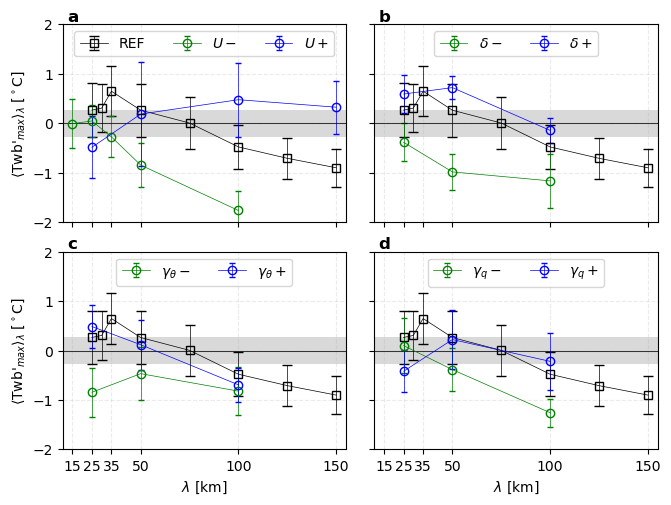

In [13]:
mrk_ref = 's'
mrk_u = 'o'
mrk_t = 'o'  # 'd'
mrk_q = 'o'  # 'X'
mrk_sm = 'o'  # 'P'

xs = lengths
xtcks = xs
xtlbs = xs

cols = ['g', 'b']

h_ref = Line2D([0, 0], [0, 0], marker=mrk_ref, color='w', markeredgecolor='k')

h_u0 = Line2D([0, 0], [0, 0], marker=mrk_u, color='w', markeredgecolor=cols[0])
h_u1 = Line2D([0, 0], [0, 0], marker=mrk_u, color='w', markeredgecolor=cols[1])
h_t0 = Line2D([0, 0], [0, 0], marker=mrk_t, color='w', markeredgecolor=cols[0])
h_t1 = Line2D([0, 0], [0, 0], marker=mrk_t, color='w', markeredgecolor=cols[1])
h_q0 = Line2D([0, 0], [0, 0], marker=mrk_q, color='w', markeredgecolor=cols[0])
h_q1 = Line2D([0, 0], [0, 0], marker=mrk_q, color='w', markeredgecolor=cols[1])
h_sm0 = Line2D([0, 0], [0, 0], marker=mrk_sm, color='w', markeredgecolor=cols[0])
h_sm1 = Line2D([0, 0], [0, 0], marker=mrk_sm, color='w', markeredgecolor=cols[1])

hs = [h_u0, h_u1, h_sm0, h_sm1, h_t0, h_t1, h_q0, h_q1]
ls = ['$U-$', '$U+$', '$\delta-$', '$\delta+$', '$\\gamma_{\\theta}-$', '$\\gamma_{\\theta}+$', '$\\gamma_{q}-$', '$\\gamma_{q}+$'] #'RH$-$', 'RH+']

xlims = (10., 155.)
xtcks = [15, 25, 35, 50, 100, 150]

fig, ax = plt.subplots(nrows=2, ncols=2)

plt.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.95, wspace=0.1, hspace=0.15)

nonsigls = [k for k in anos_ref.keys() if anos_ref[k][2] == False]
nonsigvals = [anos_ref[k][0] for k in nonsigls]
vals_ref = [val[0] for val in anos_ref.values()]
stds_ref = [val[1] for val in anos_ref.values()]

ax[0][0].errorbar(anos_ref.keys(), vals_ref, yerr=stds_ref, capsize=3.5, marker=mrk_ref, lw=0.5, color='k', markerfacecolor='none', label='REF')
ax[0][1].errorbar(anos_ref.keys(), vals_ref, yerr=stds_ref, capsize=3.5, marker=mrk_ref, lw=0.5, color='k', markerfacecolor='none')
ax[1][0].errorbar(anos_ref.keys(), vals_ref, yerr=stds_ref, capsize=3.5, marker=mrk_ref, lw=0.5, color='k', markerfacecolor='none')
ax[1][1].errorbar(anos_ref.keys(), vals_ref, yerr=stds_ref, capsize=3.5, marker=mrk_ref, lw=0.5, color='k', markerfacecolor='none')

ax[0][0].fill_between([10, 155], y1=-wet_std_all_mean, y2=wet_std_all_mean, color='k', linewidths=0, alpha=0.15)
ax[0][1].fill_between([10, 155], y1=-wet_std_all_mean, y2=wet_std_all_mean, color='k', linewidths=0, alpha=0.15)
ax[1][0].fill_between([10, 155], y1=-wet_std_all_mean, y2=wet_std_all_mean, color='k', linewidths=0, alpha=0.15)
ax[1][1].fill_between([10, 155], y1=-wet_std_all_mean, y2=wet_std_all_mean, color='k', linewidths=0, alpha=0.15)


# wind

for iu, (u, anos_u) in enumerate(out_anos_u.items()):
    xs_ = list(anos_u.keys())
    anos = [val[0] for val in anos_u.values()]
    stds = [val[1] for val in anos_u.values()]
    nonsigls = [k for k in anos_u.keys() if anos_u[k][1] < 0]
    nonsigvals = [anos_u[k][0] for k in nonsigls]

    ax[0][0].errorbar(xs_, anos, yerr=stds, capsize=2.5, marker=mrk_u, lw=0.5, color=cols[iu], markerfacecolor='none', label=ls[iu])

ax[0][0].axhline(0, 0, 1, lw=0.75, color='k', alpha=0.75)
ax[0][0].text(0.015, 1.015, "a", weight='bold', fontsize=12, transform=ax[0][0].transAxes)

ax[0][0].set_xticks(xtcks)
ax[0][0].set_xticklabels([])
ax[0][0].set_xlim(xlims[0], xlims[1])
ax[0][0].set_ylim(ylims)
ax[0][0].set_ylabel("$\\langle$%s'$_{max}\\rangle_{\lambda}$ [$^\circ$C]"%var_)
ax[0][0].grid(True, alpha=0.25, ls='--')
ax[0][0].legend(loc=legloc, ncol=3)


# SM contrast

for idsm, (dsm, anos_dsm) in enumerate(out_anos_dsm.items()):
    xs = np.asarray(list(anos_dsm.keys()))
    anos = [val[0] for val in anos_dsm.values()]
    stds = [val[1] for val in anos_dsm.values()]
    nonsigls = [k for k in anos_dsm.keys() if anos_dsm[k][1] < 0]
    nonsigvals = [anos_dsm[k][0] for k in nonsigls]

    ax[0][1].errorbar(xs, anos, yerr=stds, capsize=2.5, marker=mrk_sm, lw=0.5, color=cols[idsm], markerfacecolor='none', label=ls[idsm+2])

ax[0][1].axhline(0, 0, 1, lw=0.75, color='k', alpha=0.75)
ax[0][1].text(0.015, 1.015, "b", weight='bold', fontsize=12, transform=ax[0][1].transAxes)

ax[0][1].set_xticks(xtcks)
ax[0][1].set_xticklabels([])
ax[0][1].set_xlim(xlims[0], xlims[1])
ax[0][1].set_yticklabels([])
ax[0][1].set_ylim(ylims)
ax[0][1].grid(True, alpha=0.25, ls='--')
ax[0][1].legend(loc=legloc, ncol=2)


# dTheta/dz

for idTz, (dTz, anos_dTz) in enumerate(out_anos_dTz.items()):
    xs = np.asarray(list(anos_dTz.keys()))
    anos = [val[0] for val in anos_dTz.values()]
    stds = [val[1] for val in anos_dTz.values()]
    nonsigls = [k for k in anos_dTz.keys() if anos_dTz[k][1] < 0]
    nonsigvals = [anos_dTz[k][0] for k in nonsigls]

    ax[1][0].errorbar(xs, anos, yerr=stds, capsize=2.5, marker=mrk_t, lw=0.5, color=cols[idTz], markerfacecolor='none', label=ls[idTz+4])

ax[1][0].axhline(0, 0, 1, lw=0.75, color='k', alpha=0.75)
ax[1][0].text(0.015, 1.015, "c", weight='bold', fontsize=12, transform=ax[1][0].transAxes)

ax[1][0].set_xticks(xtcks)
ax[1][0].set_xlim(xlims[0], xlims[1])
ax[1][0].set_xlabel('$\lambda$ [km]')
ax[1][0].set_ylim(ylims)
ax[1][0].set_ylabel("$\\langle$%s'$_{max}\\rangle_{\lambda}$ [$^\circ$C]"%var_)
ax[1][0].grid(True, alpha=0.25, ls='--')
ax[1][0].legend(loc=legloc, ncol=2)


# dq/dz

for idqz, (dqz, anos_dqz) in enumerate(out_anos_dqz.items()):
    xs = np.asarray(list(anos_dqz.keys()))
    anos = [val[0] for val in anos_dqz.values()]
    stds = [val[1] for val in anos_dqz.values()]
    nonsigls = [k for k in anos_dqz.keys() if anos_dqz[k][1] < 0]
    nonsigvals = [anos_dqz[k][0] for k in nonsigls]

    ax[1][1].errorbar(xs, anos, yerr=stds, capsize=2.5, marker=mrk_q, lw=0.5, color=cols[idqz], markerfacecolor='none', label=ls[idqz+6])

ax[1][1].axhline(0, 0, 1, lw=0.75, color='k', alpha=0.75)
ax[1][1].text(0.015, 1.015, "d", weight='bold', fontsize=12, transform=ax[1][1].transAxes)

ax[1][1].set_xticks(xtcks)
ax[1][1].set_xlim(xlims[0], xlims[1])
ax[1][1].set_xlabel('$\lambda$ [km]')
ax[1][1].set_yticklabels([])
ax[1][1].set_ylim(ylims)
ax[1][1].grid(True, alpha=0.25, ls='--')
ax[1][1].legend(loc=legloc, ncol=2)

fig.set_size_inches(7., 5.)